In [ ]:
import os
import sys

# Corregimos la ruta dinámicamente para encontrar la carpeta 'src'
ruta_actual = os.getcwd()
if ruta_actual.endswith('notebooks'):
    ruta_raiz = os.path.abspath(os.path.join(ruta_actual, '..'))
else:
    ruta_raiz = ruta_actual

if ruta_raiz not in sys.path:
    sys.path.insert(0, ruta_raiz)

# Importamos las librerías gráficas y TU script generador
import matplotlib.pyplot as plt
from src.psf_generator import generate_combined_psf

print("¡Estructura conectada con éxito!")

# 1. Generamos una PSF aleatoria usando tu función
psf_matrix, info = generate_combined_psf()

# 2. La graficamos para inspección visual
plt.figure(figsize=(5, 5))
plt.imshow(psf_matrix, cmap='hot', origin='lower')
plt.title(f"PSF Aleatoria (Seeing: {info['fwhm_atmos']:.2f}\")")
plt.colorbar(label='Intensidad de Luz')
plt.show()

In [ ]:
import os
import numpy as np
from src.psf_generator import generate_combined_psf

# 1. Crear una carpeta temporal para la prueba
os.makedirs("data_prueba", exist_ok=True)

# 2. Generar y guardar 3 pares de imágenes (Sucia/Limpia)
# Nota: Para esta prueba rápida usaremos la misma PSF como sucia y una matriz aleatoria como limpia
for i in range(3):
    psf_dirty, _ = generate_combined_psf()
    galaxy_clean = np.random.rand(48, 48) # Simulamos una galaxia limpia aleatoria
    
    # Las guardamos con el formato exacto que busca tu dataset.py
    np.save(f"data_prueba/dirty_{i:04d}.npy", psf_dirty)
    np.save(f"data_prueba/clean_{i:04d}.npy", galaxy_clean)

print("¡Imágenes de prueba guardadas con éxito en 'data_prueba/'!")

In [ ]:
import torch
from torch.utils.data import DataLoader
from src.dataset import AstronomyDataset

# 1. Instanciamos tu dataset apuntando a la carpeta de prueba
dataset = AstronomyDataset(data_dir="data_prueba")
print(f"El dataset leyó correctamente el inventario. Total de imágenes: {len(dataset)}")

# 2. Creamos el DataLoader (Pediremos lotes de 2 en 2)
test_loader = DataLoader(dataset, batch_size=2, shuffle=True)

In [ ]:
# Tomamos el primer lote de la fábrica automatizada
dirty_batch, clean_batch = next(iter(test_loader))

print("=== VERIFICACIÓN DE TENSORES EN PYTORCH ===")
print(f"Forma del lote sucio (Batch, Canal, Alto, Ancho): {dirty_batch.shape}")
print(f"Forma del lote limpio (Batch, Canal, Alto, Ancho): {clean_batch.shape}")
print(f"Tipo de datos interno: {dirty_batch.dtype}")

In [ ]:
import torch
from torch.utils.data import DataLoader
from src.dataset import OnlineAstronomyDataset

print("Inicializando el dataset en modo automático (Sample 23.5) desde el .venv...")

try:
    # Instanciamos el dataset. Automáticamente buscará el sample 23.5 en tu .venv
    dataset = OnlineAstronomyDataset(pixel_scale=0.03)
    print(f"¡Éxito rotundo! Catálogo 23.5 cargado de forma interna.")
    print(f"Total de galaxias reales del Hubble disponibles: {len(dataset)}")
    
    # Extraemos la galaxia con índice 0 para verificar que la física funcione
    print("\nGenerando imágenes en tiempo real (Galaxia 0)...")
    x_o, x_t = dataset[0]
    
    print(f"-> Forma del Input sucio (x_o): {x_o.shape} (Esperado: [1, 48, 48])")
    print(f"-> Forma del Target limpio (x_t): {x_t.shape} (Esperado: [1, 48, 48])")
    print(f"-> Rango de pixeles x_o: [{x_o.min():.2f}, {x_o.max():.2f}]")
    
    # Probamos el DataLoader de PyTorch (Batch Size = 4)
    print("\nProbando el DataLoader de PyTorch (Batch Size = 4)...")
    loader = DataLoader(dataset, batch_size=4, shuffle=True)
    batch_x_o, batch_x_t = next(iter(loader))
    print(f"-> Forma final del lote: {batch_x_o.shape} (Esperado: [4, 1, 48, 48])")
    print("\n¡Todo listo! Tu pipeline de datos está 100% operativo.")

except Exception as e:
    print(f"\nOcurrió un error en el pipeline: {e}")

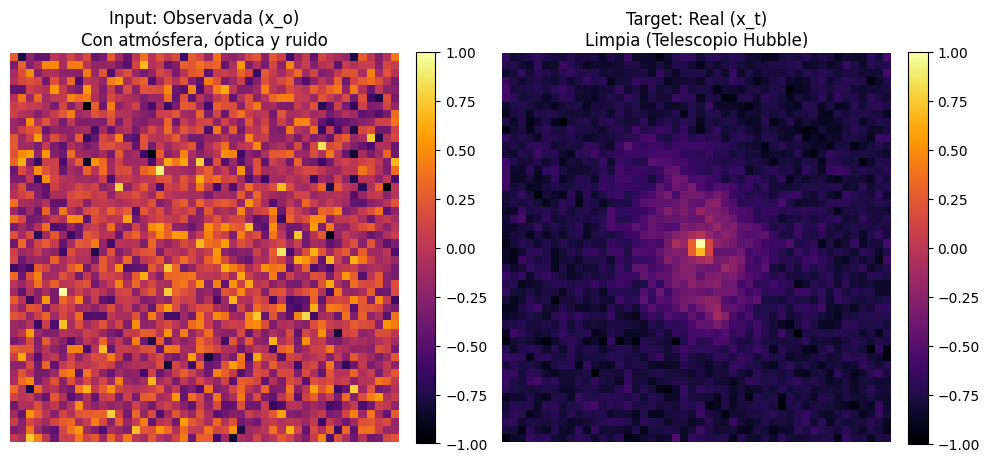

In [2]:
import matplotlib.pyplot as plt  # <--- Corregido aquí
from src.dataset import OnlineAstronomyDataset

# 1. Volver a crear el dataset
dataset = OnlineAstronomyDataset(pixel_scale=0.03)

# 2. Extraer la galaxia (puedes cambiar el índice para ver galaxias distintas)
indice_galaxia = 10
x_o_tensor, x_t_tensor = dataset[indice_galaxia]

# 3. Convertir a NumPy quitando el canal extra [1, 48, 48] -> [48, 48]
img_observada = x_o_tensor.squeeze().numpy()
img_target_limpia = x_t_tensor.squeeze().numpy()

# 4. Graficar lado a lado
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Imagen observada (con atmósfera y ruido)
im0 = axes[0].imshow(img_observada, cmap='inferno', origin='lower')
axes[0].set_title("Input: Observada (x_o)\nCon atmósfera, óptica y ruido")
axes[0].axis('off')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Imagen real (Limpia - Hubble)
im1 = axes[1].imshow(img_target_limpia, cmap='inferno', origin='lower')
axes[1].set_title("Target: Real (x_t)\nLimpia (Telescopio Hubble)")
axes[1].axis('off')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()